In [1]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import recall_score,accuracy_score,confusion_matrix,precision_score,f1_score,roc_curve,auc,multilabel_confusion_matrix
import pandas as pd
import optuna
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
X_train=pd.read_csv(r"D:\ML Project\Data Splits\X_train.csv")
X_val=pd.read_csv(r"D:\ML Project\Data Splits\X_val.csv")
X_test=pd.read_csv(r"D:\ML Project\Data Splits\X_test.csv")

Y_train=pd.read_csv(r"D:\ML Project\Data Splits\Y_train.csv")['class']
Y_val=pd.read_csv(r"D:\ML Project\Data Splits\Y_val.csv")['class']
Y_test=pd.read_csv(r"D:\ML Project\Data Splits\Y_test.csv")['class']

In [3]:
# n_estimators=list(range(50,350,50))


# learning_rate = [round(x, 2) for x in np.arange(0.1, 0.5, 0.01)]


In [4]:
def objective(trial):
    n_estimators=trial.suggest_int('n_estimators',50,300)
    learning_rate=trial.suggest_float('learning_rate',0.1,0.5)


    model=AdaBoostClassifier(n_estimators=n_estimators,learning_rate=learning_rate,random_state=50)
    model.fit(X_train,Y_train)
    Y_val_pred=model.predict(X_val)
    accuracy_val=accuracy_score(Y_val,Y_val_pred)

    return accuracy_val


study=optuna.create_study(direction='maximize')
study.optimize(objective,n_trials=50)

# direction='maximize' since we are working on acuracy which needs to be maximized

[I 2026-05-25 12:41:52,313] A new study created in memory with name: no-name-317365cd-b634-4970-8e77-1016ed33b3b1
[I 2026-05-25 12:42:51,144] Trial 0 finished with value: 0.9868 and parameters: {'n_estimators': 95, 'learning_rate': 0.16229439485298422}. Best is trial 0 with value: 0.9868.
[I 2026-05-25 12:44:40,597] Trial 1 finished with value: 0.986 and parameters: {'n_estimators': 172, 'learning_rate': 0.37346211034832155}. Best is trial 0 with value: 0.9868.
[I 2026-05-25 12:45:52,150] Trial 2 finished with value: 0.9874 and parameters: {'n_estimators': 108, 'learning_rate': 0.15773766872531453}. Best is trial 2 with value: 0.9874.
[I 2026-05-25 12:48:24,874] Trial 3 finished with value: 0.9863 and parameters: {'n_estimators': 241, 'learning_rate': 0.4016107395931485}. Best is trial 2 with value: 0.9874.
[I 2026-05-25 12:49:52,244] Trial 4 finished with value: 0.9868 and parameters: {'n_estimators': 175, 'learning_rate': 0.10161488516127269}. Best is trial 2 with value: 0.9874.
[I 2

In [5]:
optuna_AB = study.trials_dataframe()
optuna_AB.to_csv(r"D:\ML Project\Model_Tuned_Parameter_data\Optuna_AB.csv", index=False)

In [6]:
with open(r"D:\ML Project\Model_Tuned_Parameter_data\Parameters\AB.json", "w") as f:
    input=study.best_trial.params
    input['Accuracy']=study.best_trial.value
    json.dump(input, f)

In [7]:
print(f'Validation best accuracy: {study.best_trial.value}')
print(f'Validation best parameters: {study.best_trial.params}')

Validation best accuracy: 0.9884
Validation best parameters: {'n_estimators': 112, 'learning_rate': 0.27390372386065226}


In [8]:
with open(r"D:\ML Project\Model_Tuned_Parameter_data\Parameters\AB.json", "r") as f:
    loaded_dict = json.load(f)

params = dict(list(loaded_dict.items())[:-1])
validation_accuracy=loaded_dict['Accuracy']

In [9]:
model_best=AdaBoostClassifier(**params,random_state=50)  # *8 unpacks the dictionary and allows us to pass the dictionary keys as keywords (parameter keywords) in the function

# Dictionary Unpacking in Function CallsThe ** operator allows you to take key-value pairs from a dictionary and pass them as named keyword arguments to a function. Experts on Stack Overflow explain that this enables dynamic argument handling.pythondef greet(name, age):
#     print(f"Hello {name}, you are {age} years old.")

# data = {"name": "Alice", "age": 25}
# greet(**data)  # Equivalent to greet(name="Alice", age=25)
# Use code with caution.3. Collecting Arguments (**kwargs)In a function definition, ** collects any number of keyword arguments into a single dictionary, typically named kwargs. A guide on Medium highlights how this provides a shortcut for accepting flexible inputs.pythondef show_info(**kwargs):
#     for key, value in kwargs.items():
#         print(f"{key}: {value}")

# show_info(city="New York", job="Developer") 
# # kwargs becomes {'city': 'New York', 'job': 'Developer'}
# Use code with caution.4. Merging Dictionaries (Python 3.5+)You can use ** inside a dictionary literal to merge multiple dictionaries into one.pythondict1 = {"a": 1}
# dict2 = {"b": 2}
# merged = {**dict1, **dict2}  # Output: {'a': 1, 'b': 2}


model_best.fit(X_train,Y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",112
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.27390372386065226
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",50


In [10]:
Y_train_pred=model_best.predict(X_train)

Accuracy_train=accuracy_score(Y_train,Y_train_pred)

Accuracy_train       # Train Accuracy

0.9875

## Test Set Analysis ###########

In [11]:
Y_test_pred=model_best.predict(X_test)

In [12]:
Accuracy_test=accuracy_score(Y_test,Y_test_pred)
Accuracy_test                                 # Test Accuracy

0.9859

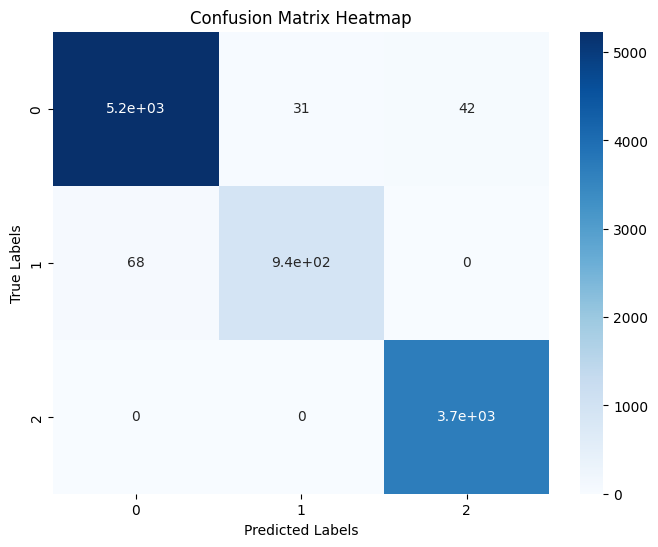

In [13]:
conf_matrix=confusion_matrix(Y_test,Y_test_pred)


plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix,annot=True,cmap='Blues')

plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [14]:
### Recall

Macro_average_recall=recall_score(Y_test,Y_test_pred,average='macro')
Per_class_recall=recall_score(Y_test,Y_test_pred,average=None)

Macro_average_recall   ## Macro Recall and accuracy both are high. So class imbalance is not a problem

0.9728807896712235

In [15]:
Per_class_recall    ## Class imbalance is not an issue as per recall since per class recall for all 3 classes is very high.

array([0.9862368 , 0.93240557, 1.        ])

In [16]:
## Precision

Macro_average_precision=precision_score(Y_test,Y_test_pred,average='macro')
Per_class_precision=precision_score(Y_test,Y_test_pred,average=None)

Macro_average_precision   ## Macro Average Precision is also very high

0.9813072089049824

In [17]:
Per_class_precision  ## Even per class precision is also very high

array([0.98716739, 0.96800826, 0.98874598])

In [18]:
## F1 score

Macro_average_f1_score=f1_score(Y_test,Y_test_pred,average='macro')
Per_class_f1_score=f1_score(Y_test,Y_test_pred,average=None)

Macro_average_f1_score   ## Macro Average Precision is also very high

0.9769721474957976

In [19]:
Per_class_f1_score

array([0.98670188, 0.94987342, 0.99434115])

In [20]:
## Sensitivity and Specificity

mcm = multilabel_confusion_matrix(Y_test,Y_test_pred)

tn = mcm[:, 0, 0]
fp = mcm[:, 0, 1]
fn = mcm[:, 1, 0]
tp = mcm[:, 1, 1]

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

sensitivity

array([0.9862368 , 0.93240557, 1.        ])

In [21]:
specificity

array([0.98551959, 0.99655326, 0.9933439 ])

In [22]:
Metrics={'Training Accuracy':Accuracy_train,'Validation Accuracy (Post Optuna Tuning)':validation_accuracy,'Test Accuracy':Accuracy_test,'Macro Average Recall':Macro_average_recall,
         'Per Class Recall':Per_class_recall,'Macro Average Precision':Macro_average_precision,'Per Class Precision':Per_class_precision,'Macro Average F1 Score':Macro_average_f1_score,
         'Per Class F1 Score':Per_class_f1_score,'Sensitivity':sensitivity,'Specificity':specificity}

Metrics=pd.Series(Metrics)

In [23]:
Metrics

Training Accuracy                                                                      0.9875
Validation Accuracy (Post Optuna Tuning)                                               0.9884
Test Accuracy                                                                          0.9859
Macro Average Recall                                                                 0.972881
Per Class Recall                                 [0.986236802413273, 0.9324055666003976, 1.0]
Macro Average Precision                                                              0.981307
Per Class Precision                         [0.9871673900735988, 0.9680082559339526, 0.988...
Macro Average F1 Score                                                               0.976972
Per Class F1 Score                          [0.986701876827313, 0.949873417721519, 0.99434...
Sensitivity                                      [0.986236802413273, 0.9324055666003976, 1.0]
Specificity                                 [0.9855195911413

In [24]:
Metrics.to_csv(r'D:\ML Project\Model_Metrics\AdaBoost.csv',header=False)